# Zero-Gain Limit Comparison

This notebook compares different zero-gain limits for a pipeline consisting of four consecutive applications of `move_plateau`.

The analyzed limits are:

- $1|V|$
- $2|V|$
- $4|V|$
- $8|V|$

It produces:

1. a comparison of relative solution quality and winner rate
2. a comparison of runtime

The analysis is grouped by graph type, size class, and density regime.

In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

plt.style.use("default")

## Configuration

In [2]:
ZERO_GAIN_FACTORS = [1, 2, 4, 8]

PLATEAU_STEPS = 4
PLATEAU_PIPELINE = ",".join(
    ["move_plateau"] * PLATEAU_STEPS
)

GRAPH_ORDER = ["powerlaw", "er"]

DATASET_ORDER = [
    "small sparse",
    "small dense",
    "large sparse",
    "large dense",
]

RESULTS_DIR = Path("../results/experiment2_new/zero_gain_limit")

RAW_RESULTS_FILE = RESULTS_DIR / "raw_results.csv"

## Load and verify experiment data

Before the analysis, the notebook lists the contained pipelines, start partitions, zero-gain factors, and number of runs. This provides a compact check that the intended experiment results were loaded.

In [3]:
raw_all = pd.read_csv(RAW_RESULTS_FILE)

required_columns = {
    "pipeline",
    "start_partition",
    "zero_gain_factor",
    "run",
    "graph_type",
    "size_class",
    "regime",
    "dataset",
    "instance",
    "final_density",
    "ls_runtime",
    "num_moves",
    "num_passes",
}

missing_columns = required_columns.difference(raw_all.columns)

if missing_columns:
    raise ValueError("Missing required columns: " + ", ".join(sorted(missing_columns)))

experiment_check = (
    raw_all
    .groupby(
        [
            "pipeline",
            "start_partition",
            "zero_gain_factor",
        ],
        dropna=False,
        as_index=False,
    )
    .agg(
        num_runs=("run", "nunique"),
        num_instances=("instance", "nunique"),
        num_rows=("run", "size"),
    )
    .sort_values(
        [
            "pipeline",
            "start_partition",
            "zero_gain_factor",
        ],
        na_position="first",
    )
    .reset_index(drop=True)
)

print(f"Loaded {len(raw_all):,} rows from {RAW_RESULTS_FILE}")

experiment_check

Loaded 640,000 rows from ../results/experiment2_new/zero_gain_limit/raw_results.csv


,pipeline,start_partition,zero_gain_factor,num_runs,num_instances,num_rows
0,"move_plateau,move_plateau,move_plateau,move_pl...",high_degree_first_matching,1,10,2000,20000
1,"move_plateau,move_plateau,move_plateau,move_pl...",high_degree_first_matching,2,10,2000,20000
2,"move_plateau,move_plateau,move_plateau,move_pl...",high_degree_first_matching,4,10,2000,20000
3,"move_plateau,move_plateau,move_plateau,move_pl...",high_degree_first_matching,8,10,2000,20000
4,"move_plateau,move_plateau,move_plateau,move_pl...",high_degree_product_matching,1,10,2000,20000
5,"move_plateau,move_plateau,move_plateau,move_pl...",high_degree_product_matching,2,10,2000,20000
6,"move_plateau,move_plateau,move_plateau,move_pl...",high_degree_product_matching,4,10,2000,20000
7,"move_plateau,move_plateau,move_plateau,move_pl...",high_degree_product_matching,8,10,2000,20000
8,"move_plateau,move_plateau,move_plateau,move_pl...",kapoce,1,10,2000,20000
9,"move_plateau,move_plateau,move_plateau,move_pl...",kapoce,2,10,2000,20000


## Prepare zero-gain experiments

In [4]:
raw_all["dataset_group"] = (
        raw_all["size_class"].astype(str)
        + " "
        + raw_all["regime"].astype(str)
)

raw_all["graph_type"] = pd.Categorical(
    raw_all["graph_type"],
    categories=GRAPH_ORDER,
    ordered=True,
)

raw_all["dataset_group"] = pd.Categorical(
    raw_all["dataset_group"],
    categories=DATASET_ORDER,
    ordered=True,
)

zero_gain_raw = raw_all[
    (raw_all["pipeline"] == PLATEAU_PIPELINE)
    & (raw_all['zero_gain_factor'].isin(ZERO_GAIN_FACTORS))
].copy()

if zero_gain_raw.empty:
    raise ValueError("No rows found for the expected four-step move_plateau pipeline.")

observed_factors = sorted(zero_gain_raw["zero_gain_factor"].dropna().astype(int).unique())

if observed_factors != ZERO_GAIN_FACTORS:
    raise ValueError(f"Expected zero-gain factors {ZERO_GAIN_FACTORS}, but found {observed_factors}.")

zero_gain_raw["zero_gain_factor"] = pd.Categorical(
    zero_gain_raw["zero_gain_factor"].astype(int),
    categories=ZERO_GAIN_FACTORS,
    ordered=True,
)

# Solution quality

For every instance and zero_gain_factor, only the run with the highest final solution quality is retained.

The best result across all compared factors is used as the reference. Relative solution quality is defined as

$
\frac{\text{best result across all factors}}
     {\text{result of the respective factor}}.
$

A value of $1.0$ means that the factor matches the best result found on the same instance. Values greater than $1.0$ indicate the remaining quality gap.

In [5]:
best_run_keys = [
    "graph_type",
    "dataset_group",
    "dataset",
    "instance",
    "zero_gain_factor",
]

best_runs = (
    zero_gain_raw
    .sort_values(
        [
            "final_density",
            "ls_runtime",
            "run",
        ],
        ascending=[
            False,
            True,
            True,
        ],
    )
    .groupby(
        best_run_keys,
        observed=True,
        as_index=False,
    )
    .head(1)
    .reset_index(drop=True)
)


In [6]:
instance_keys = [
    "graph_type",
    "dataset_group",
    "dataset",
    "instance",
]

density_table = best_runs.pivot_table(
    index=instance_keys,
    columns="zero_gain_factor",
    values="final_density",
    observed=True,
)

density_table = density_table[ZERO_GAIN_FACTORS]
density_table.columns.name = "zero_gain_factor"

if density_table.isna().any().any():
    incomplete_instances = density_table[density_table.isna().any(axis=1)]
    raise ValueError(f"{len(incomplete_instances)} instances do not contain results for all zero-gain factors.")

In [7]:
best_per_instance = density_table.max(axis=1)

relative_to_best = density_table.rdiv(best_per_instance, axis=0)

relative_quality_summary = (
    relative_to_best
    .groupby(
        level=["graph_type", "dataset_group"]
    )
    .agg(["mean", "min", "max"])
    .stack(level=0, future_stack=True)
    .reset_index()
    .rename(
        columns={
            "mean": "mean_relative_to_best",
            "min": "min_relative_to_best",
            "max": "max_relative_to_best",
        }
    )
)

relative_quality_summary

,graph_type,dataset_group,zero_gain_factor,mean_relative_to_best,min_relative_to_best,max_relative_to_best
0,powerlaw,small sparse,1,1.000809,1.0,1.007800
1,powerlaw,small sparse,2,1.000505,1.0,1.005603
2,powerlaw,small sparse,4,1.000457,1.0,1.006148
3,powerlaw,small sparse,8,1.000370,1.0,1.003920
4,powerlaw,small dense,1,1.002967,1.0,1.015669
5,powerlaw,small dense,2,1.001471,1.0,1.011084
6,powerlaw,small dense,4,1.001398,1.0,1.008572
7,powerlaw,small dense,8,1.001254,1.0,1.008547
8,powerlaw,large sparse,1,1.001350,1.0,1.004002
9,powerlaw,large sparse,2,1.000619,1.0,1.003164


## Winner rates

A zero-gain factor is counted as a winner whenever it reaches the best value on an instance. Ties are counted for every involved factor.

In [8]:
is_best = density_table.eq(best_per_instance, axis=0)

best_counts = (
    is_best
    .groupby(
        level=["graph_type", "dataset_group"]
    )
    .sum()
)

best_counts.columns.name = "zero_gain_factor"

num_instances = (
    density_table
    .groupby(level=["graph_type", "dataset_group"])
    .size()
    .rename("num_instances")
    .reset_index()
)

winner_counts = (
    best_counts
    .stack()
    .rename("best_count_with_ties")
    .reset_index()
    .merge(
        num_instances,
        on=["graph_type", "dataset_group"],
    )
)

winner_counts["winner_rate"] = (
        winner_counts["best_count_with_ties"]
        / winner_counts["num_instances"]
)

winner_counts

,graph_type,dataset_group,zero_gain_factor,best_count_with_ties,num_instances,winner_rate
0,powerlaw,small sparse,1,148,250,0.592
1,powerlaw,small sparse,2,179,250,0.716
2,powerlaw,small sparse,4,176,250,0.704
3,powerlaw,small sparse,8,190,250,0.760
4,powerlaw,small dense,1,64,250,0.256
5,powerlaw,small dense,2,116,250,0.464
6,powerlaw,small dense,4,122,250,0.488
7,powerlaw,small dense,8,134,250,0.536
8,powerlaw,large sparse,1,18,250,0.072
9,powerlaw,large sparse,2,76,250,0.304


In [9]:
DATASET_LABELS = {
    "large dense": "large dense",
    "large sparse": "large sparse",
    "small dense": "small dense",
    "small sparse": "small sparse",
}

GRAPH_TYPE_LABELS = {
    "er": "Erdős–Rényi",
    "powerlaw": "Powerlaw",
}

In [10]:
def plot_relative_quality(summary: pd.DataFrame, graph_type: str, output_path: str | None = None) -> None:
    graph_data = (
        summary[summary["graph_type"] == graph_type]
        .sort_values(["dataset_group", "zero_gain_factor",])
    )

    fig, ax = plt.subplots(figsize=(8, 5))

    for dataset_group, group_data in graph_data.groupby("dataset_group", observed=True):
        ax.plot(
            group_data["zero_gain_factor"].astype(int),
            group_data["mean_relative_to_best"],
            marker="o",
            linewidth=2,
            markersize=5,
            label=dataset_group,
        )

    ax.axhline(
        1.0,
        linestyle="--",
        color="gray",
        linewidth=1,
        label="Beste gefundene Lösung",
    )

    ax.set_xlabel("Zero-Gain-Limit")
    ax.set_ylabel("Mittlere relative Lösungsqualität")
    ax.set_title(f"Relative Lösungsqualität ({GRAPH_TYPE_LABELS[graph_type]})")

    ax.set_xticks(ZERO_GAIN_FACTORS)
    ax.set_xticklabels([f"{factor}|V|" for factor in ZERO_GAIN_FACTORS])

    ax.set_ylim(
        graph_data["mean_relative_to_best"].min() - 0.0005,
        graph_data["mean_relative_to_best"].max() + 0.0005,
    )

    ax.legend(title="Datensatzgruppe")
    ax.grid(axis="y", alpha=0.3)

    fig.tight_layout()

    if output_path is not None:
        fig.savefig(
            output_path,
            bbox_inches="tight",
            facecolor="white",
        )

    plt.show()
    plt.close(fig)

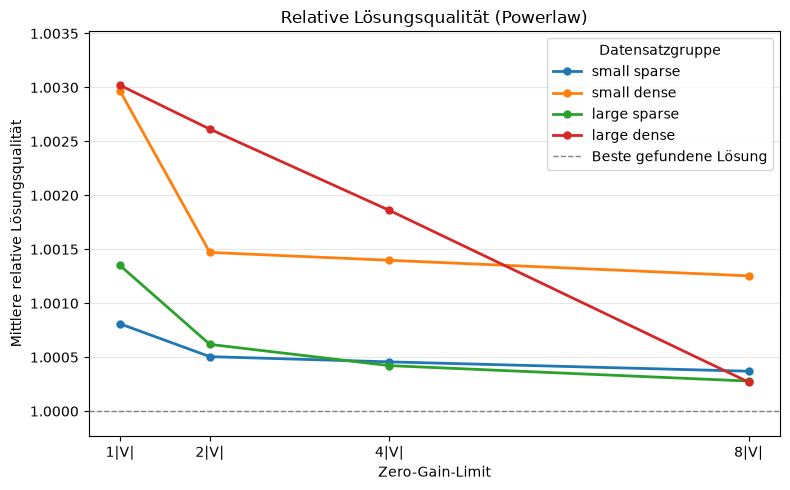

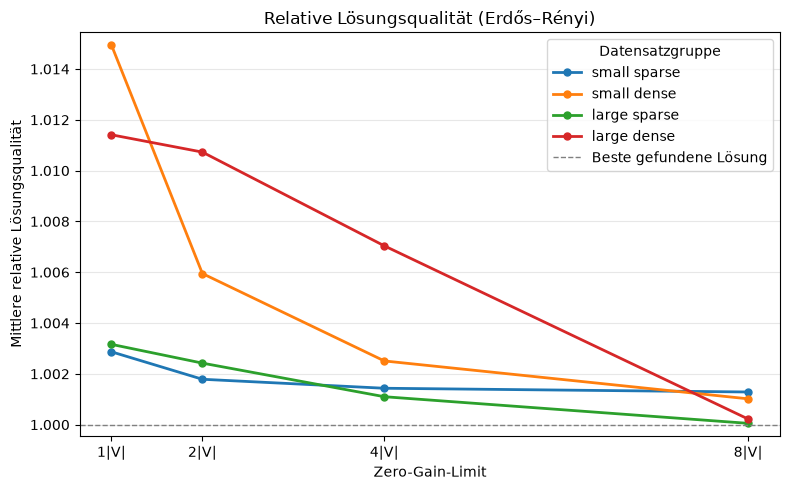

In [11]:
plot_relative_quality(
    relative_quality_summary,
    "powerlaw",
    "../results/plots/powerlaw_zero_gain_quality.png"
)

plot_relative_quality(
    relative_quality_summary,
    "er",
    "../results/plots/er_zero_gain_quality.png"
)

## Runtime

The reported runtime is the total local-search runtime of all runs for one instance and operator, averaged over all instances in the corresponding dataset group.

In [12]:
runtime_per_instance = (
    zero_gain_raw
    .groupby(
        best_run_keys,
        observed=True,
    )
    .agg(
        total_runtime=("ls_runtime", "sum"),
        moves_per_run=("num_moves", "mean"),
        passes_per_run=("num_passes", "mean"),
    )
    .reset_index()
)

runtime_summary = (
    runtime_per_instance
    .groupby(
        [
            "graph_type",
            "dataset_group",
            "zero_gain_factor",
        ],
        observed=True,
    )
    .agg(
        mean_runtime=("total_runtime", "mean"),
        mean_moves_per_run=("moves_per_run", "mean"),
        mean_passes_per_run=("passes_per_run", "mean"),
    )
    .reset_index()
    .rename(columns={"pipeline": "operator"})
)

runtime_summary

,graph_type,dataset_group,zero_gain_factor,mean_runtime,mean_moves_per_run,mean_passes_per_run
0,powerlaw,small sparse,1,28.871915,649.31635,73.24270
1,powerlaw,small sparse,2,61.011081,1246.68450,165.33565
2,powerlaw,small sparse,4,127.627222,2441.42100,356.15580
3,powerlaw,small sparse,8,263.124954,4830.04360,742.80820
4,powerlaw,small dense,1,50.231958,655.83720,54.55060
5,powerlaw,small dense,2,110.396184,1254.56080,125.28700
6,powerlaw,small dense,4,238.732760,2450.73415,277.41540
7,powerlaw,small dense,8,498.208946,4842.45995,586.35045
8,powerlaw,large sparse,1,231.014780,4353.62975,59.53105
9,powerlaw,large sparse,2,478.513178,8385.21050,131.51165


In [13]:
def plot_total_runtime(summary: pd.DataFrame, graph_type: str, output_path: str | None = None) -> None:
    graph_data = (
        summary[summary["graph_type"] == graph_type]
        .sort_values(["dataset_group", "zero_gain_factor"])
    )

    fig, ax = plt.subplots(figsize=(8, 5))

    for dataset_group, group_data in graph_data.groupby("dataset_group", observed=True):
        ax.plot(
            group_data["zero_gain_factor"].astype(int),
            group_data["mean_runtime"],
            marker="o",
            linewidth=2,
            markersize=5,
            label=dataset_group,
        )

    ax.set_xlabel("Zero-Gain-Limit")
    ax.set_ylabel("Mittlere Gesamtlaufzeit aller Runs (s)")
    ax.set_title(f"Gesamtlaufzeit ({GRAPH_TYPE_LABELS[graph_type]})")

    ax.set_xticks(ZERO_GAIN_FACTORS)
    ax.set_xticklabels([f"{factor}|V|" for factor in ZERO_GAIN_FACTORS])

    ax.legend(title="Datensatzgruppe")
    ax.grid(axis="y", alpha=0.3)

    fig.tight_layout()

    if output_path is not None:
        fig.savefig(
            output_path,
            bbox_inches="tight",
            facecolor="white",
        )

    plt.show()
    plt.close(fig)

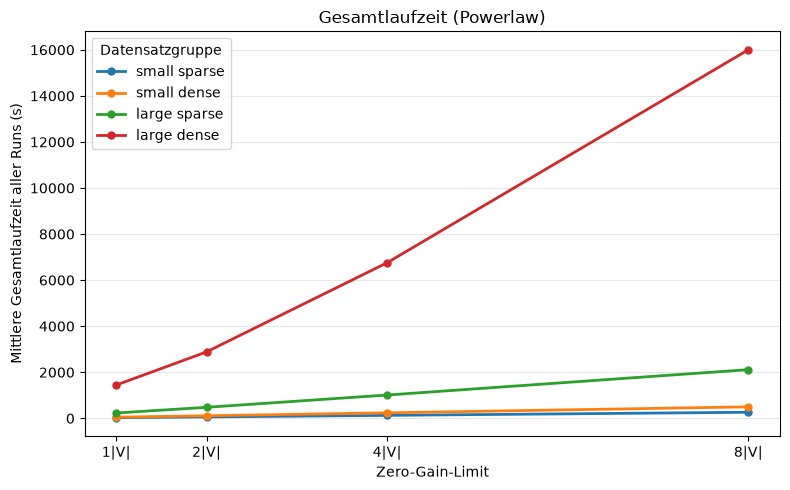

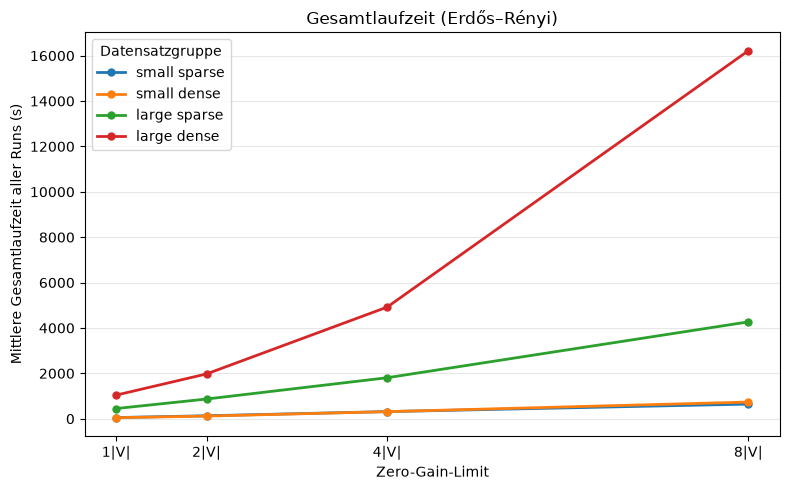

In [14]:
plot_total_runtime(
    runtime_summary,
    "powerlaw",
    "../results/plots/powerlaw_zero_gain_runtime.png"
)

plot_total_runtime(
    runtime_summary,
    "er",
    "../results/plots/er_zero_gain_runtime.png"
)

## Combined comparison data

In [15]:
comparison_summary = (
    relative_quality_summary
    .merge(
        winner_counts[
            [
                "graph_type",
                "dataset_group",
                "zero_gain_factor",
                "winner_rate",
            ]
        ],
        on=[
            "graph_type",
            "dataset_group",
            "zero_gain_factor",
        ],
    )
    .merge(
        runtime_summary,
        on=[
            "graph_type",
            "dataset_group",
            "zero_gain_factor",
        ],
    )
)

comparison_summary["zero_gain_factor"] = pd.Categorical(
    comparison_summary["zero_gain_factor"],
    categories=ZERO_GAIN_FACTORS,
    ordered=True,
)

comparison_summary = (
    comparison_summary
    .sort_values(
        [
            "graph_type",
            "dataset_group",
            "zero_gain_factor",
        ]
    )
    .reset_index(drop=True)
)

comparison_summary

,graph_type,dataset_group,zero_gain_factor,mean_relative_to_best,min_relative_to_best,max_relative_to_best,winner_rate,mean_runtime,mean_moves_per_run,mean_passes_per_run
0,powerlaw,small sparse,1,1.000809,1.0,1.007800,0.592,28.871915,649.31635,73.24270
1,powerlaw,small sparse,2,1.000505,1.0,1.005603,0.716,61.011081,1246.68450,165.33565
2,powerlaw,small sparse,4,1.000457,1.0,1.006148,0.704,127.627222,2441.42100,356.15580
3,powerlaw,small sparse,8,1.000370,1.0,1.003920,0.760,263.124954,4830.04360,742.80820
4,powerlaw,small dense,1,1.002967,1.0,1.015669,0.256,50.231958,655.83720,54.55060
5,powerlaw,small dense,2,1.001471,1.0,1.011084,0.464,110.396184,1254.56080,125.28700
6,powerlaw,small dense,4,1.001398,1.0,1.008572,0.488,238.732760,2450.73415,277.41540
7,powerlaw,small dense,8,1.001254,1.0,1.008547,0.536,498.208946,4842.45995,586.35045
8,powerlaw,large sparse,1,1.001350,1.0,1.004002,0.072,231.014780,4353.62975,59.53105
9,powerlaw,large sparse,2,1.000619,1.0,1.003164,0.304,478.513178,8385.21050,131.51165


## LaTeX helper functions

In [16]:
def truncate_number(value: float, decimals: int) -> float:
    factor = 10 ** decimals
    return np.trunc(value * factor) / factor


def latex_factor(factor: int) -> str:
    return rf"${factor}|V|$"


def format_number(value: float, decimals: int) -> str:
    return f"{value:.{decimals}f}"


def format_percent(value: float, decimals: int = 1) -> str:
    return (
        f"{truncate_number(100 * value, decimals):.{decimals}f}"
        r",\%"
    )

## Build quality LaTeX table

In [17]:
def make_quality_latex_table(df: pd.DataFrame, caption: str, label: str) -> str:
    graph_labels = {
        "powerlaw": "Powerlaw",
        "er": r"Erdős-Rényi",
    }

    lines = [
        r"\begin{table}[t]",
        r"\centering",
        rf"\caption{{{caption}}}",
        rf"\label{{{label}}}",
        r"\begin{tabular}{lllrr}",
        r"\toprule",
        (
            r"Graphentyp & Datensatz & Zero-Gain-Limit "
            r"& \shortstack{Mittlere relative\\Lösungsqualität} & Gewinnrate \\"
        ),
        r"\midrule",
    ]

    for graph_type in GRAPH_ORDER:
        graph_df = df[df["graph_type"] == graph_type]

        if graph_df.empty:
            continue

        for dataset_index, dataset in enumerate(DATASET_ORDER):
            part = graph_df[graph_df["dataset_group"] == dataset].copy()

            if part.empty:
                continue

            part = part.sort_values("zero_gain_factor")

            best_mean = part["mean_relative_to_best"].min()

            for i, row in enumerate(part.itertuples(index=False)):
                graph_cell = (
                    rf"\multirow{{16}}{{*}}"
                    rf"{{{graph_labels[graph_type]}}}"
                    if dataset_index == 0 and i == 0
                    else ""
                )
                dataset_cell = (
                    rf"\multirow{{4}}{{*}}{{{dataset}}}"
                    if i == 0
                    else ""
                )

                mean = format_number(
                    row.mean_relative_to_best,
                    6,
                )
                winner_rate = format_percent(
                    row.winner_rate,
                    1,
                )

                if np.isclose(row.mean_relative_to_best, best_mean):
                    mean = rf"\textbf{{{mean}}}"

                lines.append(
                    f"{graph_cell} & {dataset_cell} "
                    f"& {latex_factor(str(row.zero_gain_factor))} "
                    f"& {mean} & {winner_rate} \\\\"
                )

            if dataset_index < len(DATASET_ORDER) - 1:
                lines.append(r"\cmidrule(l){2-5}")
            else:
                lines.append(r"\midrule")

    lines[-1] = r"\bottomrule"
    lines.extend(
        [
            r"\end{tabular}",
            r"\end{table}",
        ]
    )

    return "\n".join(lines)


quality_latex = make_quality_latex_table(
    comparison_summary,
    caption=(
        "Mittlere relative Lösungsqualität und Gewinnrate für verschiedene Zero-Gain-Limits auf Powerlaw- und Erdős-Rényi-Instanzen. Die relative Lösungsqualität ist der Quotient aus der besten auf derselben Instanz gefundenen Lösung und der Lösung des jeweiligen Limits. Ein Wert von 1 entspricht der besten gefundenen Lösung."
    ),
    label="tab:zero_gain_quality",
)

print(quality_latex)

\begin{table}[t]
\centering
\caption{Mittlere relative Lösungsqualität und Gewinnrate für verschiedene Zero-Gain-Limits auf Powerlaw- und Erdős-Rényi-Instanzen. Die relative Lösungsqualität ist der Quotient aus der besten auf derselben Instanz gefundenen Lösung und der Lösung des jeweiligen Limits. Ein Wert von 1 entspricht der besten gefundenen Lösung.}
\label{tab:zero_gain_quality}
\begin{tabular}{lllrr}
\toprule
Graphentyp & Datensatz & Zero-Gain-Limit & \shortstack{Mittlere relative\\Lösungsqualität} & Gewinnrate \\
\midrule
\multirow{16}{*}{Powerlaw} & \multirow{4}{*}{small sparse} & $1|V|$ & 1.000809 & 59.2,\% \\
 &  & $2|V|$ & 1.000505 & 71.6,\% \\
 &  & $4|V|$ & 1.000457 & 70.3,\% \\
 &  & $8|V|$ & \textbf{1.000370} & 76.0,\% \\
\cmidrule(l){2-5}
 & \multirow{4}{*}{small dense} & $1|V|$ & 1.002967 & 25.6,\% \\
 &  & $2|V|$ & 1.001471 & 46.4,\% \\
 &  & $4|V|$ & 1.001398 & 48.8,\% \\
 &  & $8|V|$ & \textbf{1.001254} & 53.6,\% \\
\cmidrule(l){2-5}
 & \multirow{4}{*}{large sparse}

## Build runtime LaTeX table

In [18]:
def make_runtime_latex_table(df: pd.DataFrame, caption: str, label: str) -> str:
    graph_labels = {
        "powerlaw": "Powerlaw",
        "er": r"Erdős-Rényi",
    }

    lines = [
        r"\begin{table}[t]",
        r"\centering",
        rf"\caption{{{caption}}}",
        rf"\label{{{label}}}",
        r"\begin{tabular}{lllrrr}",
        r"\toprule",
        (
            r"Graphentyp & Datensatz & Zero-Gain-Limit & Laufzeit (s) "
            r"& Moves & Durchläufe \\"
        ),
        r"\midrule",
    ]

    for graph_type in GRAPH_ORDER:
        graph_df = df[df["graph_type"] == graph_type]

        for dataset_index, dataset in enumerate(DATASET_ORDER):
            part = graph_df[graph_df["dataset_group"] == dataset].copy()

            if part.empty:
                continue

            part = part.sort_values("zero_gain_factor")

            for i, row in enumerate(part.itertuples(index=False)):
                graph_cell = (
                    rf"\multirow{{16}}{{*}}"
                    rf"{{{graph_labels[graph_type]}}}"
                    if dataset_index == 0 and i == 0
                    else ""
                )
                dataset_cell = (
                    rf"\multirow{{4}}{{*}}{{{dataset}}}"
                    if i == 0
                    else ""
                )

                lines.append(
                    f"{graph_cell} & {dataset_cell} "
                    f"& {latex_factor(str(row.zero_gain_factor))} "
                    f"& {format_number(row.mean_runtime, 2)} "
                    f"& {format_number(row.mean_moves_per_run, 1)} "
                    f"& {format_number(row.mean_passes_per_run, 1)} \\\\"
                )

            if dataset_index < len(DATASET_ORDER) - 1:
                lines.append(r"\cmidrule(l){2-6}")
            else:
                lines.append(r"\midrule")

    lines[-1] = r"\bottomrule"
    lines.extend(
        [
            r"\end{tabular}",
            r"\end{table}",
        ]
    )

    return "\n".join(lines)


runtime_latex = make_runtime_latex_table(
    comparison_summary,
    caption=(
        "Mittlere Gesamtlaufzeit der zehn Runs sowie durchschnittliche Anzahl ausgeführter Knotenverschiebungen und Durchläufe für verschiedene Zero-Gain-Limits auf Powerlaw- und Erdős-Rényi-Instanzen."
    ),
    label="tab:zero_gain_runtime",
)

print(runtime_latex)

\begin{table}[t]
\centering
\caption{Mittlere Gesamtlaufzeit der zehn Runs sowie durchschnittliche Anzahl ausgeführter Knotenverschiebungen und Durchläufe für verschiedene Zero-Gain-Limits auf Powerlaw- und Erdős-Rényi-Instanzen.}
\label{tab:zero_gain_runtime}
\begin{tabular}{lllrrr}
\toprule
Graphentyp & Datensatz & Zero-Gain-Limit & Laufzeit (s) & Moves & Durchläufe \\
\midrule
\multirow{16}{*}{Powerlaw} & \multirow{4}{*}{small sparse} & $1|V|$ & 28.87 & 649.3 & 73.2 \\
 &  & $2|V|$ & 61.01 & 1246.7 & 165.3 \\
 &  & $4|V|$ & 127.63 & 2441.4 & 356.2 \\
 &  & $8|V|$ & 263.12 & 4830.0 & 742.8 \\
\cmidrule(l){2-6}
 & \multirow{4}{*}{small dense} & $1|V|$ & 50.23 & 655.8 & 54.6 \\
 &  & $2|V|$ & 110.40 & 1254.6 & 125.3 \\
 &  & $4|V|$ & 238.73 & 2450.7 & 277.4 \\
 &  & $8|V|$ & 498.21 & 4842.5 & 586.4 \\
\cmidrule(l){2-6}
 & \multirow{4}{*}{large sparse} & $1|V|$ & 231.01 & 4353.6 & 59.5 \\
 &  & $2|V|$ & 478.51 & 8385.2 & 131.5 \\
 &  & $4|V|$ & 1011.43 & 16443.3 & 286.4 \\
 &  & $8|V|$ 